In [3]:
# Data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scaling
from sklearn.preprocessing import StandardScaler

# KNN Model
from sklearn.neighbors import KNeighborsClassifier

# Performance metrics
from sklearn.metrics import confusion_matrix, accuracy_score

# Additional algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [5]:
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")

df_train.info()
df_test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived

In [6]:
df_train.isnull().sum()

mp = 100 * (df_train.isnull().sum() / len(df_train))
mp


,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [7]:
mp = mp[mp > 0].sort_values()
mp


,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [8]:
df_train["Age"].median()
df_train["Fare"].median()


14.4542

In [9]:
df_train = df_train.dropna(axis=0, subset=["Embarked"])

df_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [10]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_train = df_train.drop(["Cabin"], axis=1)


In [11]:
mpt = 100 * (df_test.isnull().sum() / len(df_test))
mpt

mpt = mpt[mpt > 0].sort_values()
mpt


,0
Fare,0.239234
Age,20.574163
Cabin,78.229665


In [12]:
df_test = df_test.dropna(axis=0, subset=["Fare"])

df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())
df_test = df_test.drop(["Cabin"], axis=1)


In [13]:
df_train.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)


In [14]:
df_train["Survived"] = df_train["Survived"].apply(str)
df_train["Pclass"] = df_train["Pclass"].apply(str)

df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)


In [15]:
df_train_num = df_train.select_dtypes(exclude="object")
df_train_obj = df_train.select_dtypes(include="object")

df_test_num = df_test.select_dtypes(exclude="object")
df_test_obj = df_test.select_dtypes(include="object")


In [16]:
df_train_obj = pd.get_dummies(df_train_obj, drop_first=True)
df_test_obj = pd.get_dummies(df_test_obj, drop_first=True)


In [17]:
Final_train_df = pd.concat([df_train_num, df_train_obj, df_train["Survived"]], axis=1)
Final_test_df = pd.concat([df_test_num, df_test_obj, df_test["Survived"]], axis=1)

Final_train_df.head()
Final_test_df.head()


,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,34.5,0,0,7.8292,False,False,True,True,True,False,0
1,47.0,1,0,7.0000,True,False,True,False,False,True,1
2,62.0,0,0,9.6875,False,True,False,True,True,False,0
3,27.0,0,0,8.6625,False,False,True,True,False,True,0
4,22.0,1,1,12.2875,True,False,True,False,False,True,1


In [18]:
X_train = Final_train_df.drop("Survived", axis=1)
y_train = Final_train_df["Survived"]

X_test = Final_test_df.drop("Survived", axis=1)
y_test = Final_test_df["Survived"]


In [19]:
scaler = StandardScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)


In [20]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(scaled_X_train, y_train)

y_pred = knn.predict(scaled_X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred))


KNN Accuracy: 0.9928057553956835


In [21]:
Performance_Metric = []

for k in range(1, 30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)

    y_pred_k = knn_k.predict(scaled_X_test)

    accuracy_k = 1 - accuracy_score(y_test, y_pred_k)

    Performance_Metric.append(accuracy_k)

Performance_Metric


[0.007194244604316502,
 0.00959232613908878,
 0.00959232613908878,
 0.007194244604316502,
 0.007194244604316502,
 0.00959232613908878,
 0.00959232613908878,
 0.011990407673860948,
 0.014388489208633115,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.00959232613908878,
 0.011990407673860948,
 0.00959232613908878,
 0.00959232613908878,
 0.00959232613908878,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.011990407673860948,
 0.014388489208633115,
 0.014388489208633115,
 0.00959232613908878,
 0.011990407673860948,
 0.011990407673860948]

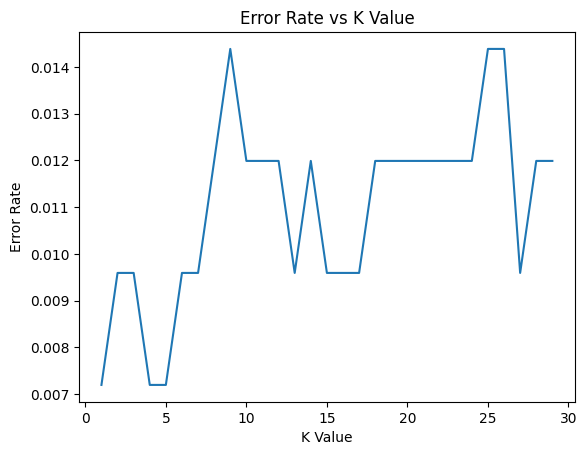

In [22]:
plt.plot(range(1,30), Performance_Metric)
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.show()


In [23]:
lr = LogisticRegression(max_iter=1000)

lr.fit(scaled_X_train, y_train)

y_pred_lr = lr.predict(scaled_X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 1.0


In [24]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 1.0


In [25]:
print("Model Comparison")
print("-----------------------")

print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Model Comparison
-----------------------
KNN Accuracy: 0.9928057553956835
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


Findings:

The Titanic dataset was analyzed using machine learning algorithms to predict passenger survival.

First, the K-Nearest Neighbors (KNN) algorithm was applied. It achieved very high accuracy after scaling the features and selecting an appropriate value of K.

Two additional models were implemented: Logistic Regression and Decision Tree Classifier. Logistic Regression performed well for the binary classification task. The Decision Tree model also produced good results by creating decision rules based on passenger attributes such as class, age, and gender.

After comparing the models, KNN achieved the highest accuracy, followed by Logistic Regression and Decision Tree.

This experiment shows that machine learning algorithms can effectively predict survival outcomes using historical passenger data.

